<a href="https://colab.research.google.com/github/fzunigaGH/Proyectos/blob/main/Detecci%C3%B3n_temprana_de_enfermedades_carf%C3%ADacas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Diccionario de Datos

1. **X (Patient ID/No.):** Número o identificación única asociada a cada paciente en la
base de datos.
2. **Category (diagnosis):** Categoría que indica el diagnóstico relacionado con la
hepatitis C para cada paciente.
3. **Age (in years):** Edad del paciente en años al momento de la detección o registro en
la base de datos.
4. **Sex (f,m):** Género del paciente, indicado por "f" para femenino y "m" para masculino.
5. **ALB:** Albúmina, una proteína producida por el hígado. Los niveles de albúmina
pueden indicar la función hepática.
6. **ALP:** Fosfatasa alcalina, una enzima que puede estar relacionada con la función
hepática y otros procesos.
7. **ALT:** Alanina aminotransferasa, una enzima que puede indicar daño hepático.
8. **AST:** Aspartato aminotransferasa, una enzima que también puede indicar daño
hepático.
9. **BIL:** Bilirrubina, un pigmento amarillo que puede aumentar en casos de problemas
hepáticos.
10. **CHE:** Colinesterasa, una enzima que puede estar asociada con la función hepática y
otros procesos.
11. **CHOL:** Colesterol, un lípido que puede estar relacionado con la salud del hígado.
12. **CREA:** Creatinina, un producto de desecho que se filtra a través de los riñones.
13. **GGT:** Gamma-glutamil transferasa, una enzima que puede estar relacionada con la
función hepática.
14. **PROT:** Proteínas totales, que pueden incluir varias proteínas, como albúmina y globulinas.

#1. librerías, funciones y carga de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, chi2_contingency

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import roc_curve, roc_auc_score, classification_report


from sklearn.linear_model import LogisticRegressionCV
from xgboost import XGBRFClassifier

from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/06 - Modelos Avanzados/03 - Modelos de ensamble (parte III)/hcvdat0.csv', sep = ',')

##Funciones

In [ ]:
def calidad_datos(datos):
  tipos = pd.DataFrame(datos.dtypes, columns = ['tipo'])
  nan = pd.DataFrame(datos.isna().sum(), columns = ['nan'])
  nan_prop = pd.DataFrame(datos.isna().sum()/datos.shape[0]*100, columns = ['porcentaje_nan'])
  ceros = pd.DataFrame([datos.loc[datos[col] == 0, col].shape[0]  for col in datos.columns], \
                       columns = ['ceros'], index = datos.columns)
  ceros_prop = pd.DataFrame([datos.loc[datos[col] == 0, col].shape[0]/datos.shape[0]*100  for col in datos.columns],\
                       columns = ['porcentaje_ceros'], index = datos.columns)

  resumen = datos.describe(include = 'all').T
  resumen['IQR'] = resumen['75%'] - resumen['25%']
  resumen['lim_inf'] = resumen['25%'] - resumen['IQR']*1.5
  resumen['lim_sup'] = resumen['75%'] + resumen['IQR']*1.5

  resumen['atipicos'] = datos.apply(lambda x: sum(np.where((x < resumen['lim_inf'][x.name]) | (x > resumen['lim_sup'][x.name]), 1, 0)) \
                                    if x.name in resumen['lim_inf'].dropna().index else 0)

  return pd.concat([tipos, nan, nan_prop, ceros, ceros_prop, resumen], axis = 1).sort_values('tipo')

def graficos(calidad, datos, cols):
  num_cols = len(cols)
  num_rows = (num_cols + 2) // 3
  plt.figure(figsize = (15, 3 * num_rows))
  for n, i in enumerate(cols):
    plt.subplot(num_rows, 3, n+1)
    if calidad.loc[i, 'tipo'] == 'object':
      sns.countplot(y = datos[i], order = datos[i].value_counts().iloc[:16].index)
      plt.title(f'Frecuencias para {i}')
      plt.tight_layout()
    else:
      sns.distplot(datos[i])
      plt.title(f'Distribución para {i}')
      plt.tight_layout()

def no_atipicos(columna):
  q1 = columna.quantile(0.25)
  q3 = columna.quantile(0.75)
  rango_iq = q3 - q1
  lim_inf = q1 - 1.5*rango_iq
  lim_sup = q3 + 1.5*rango_iq
  condicion = (columna >= lim_inf) & (columna <= lim_sup) # & and en pandas, | or en pandas
  return condicion

def correlacion(datos, target, dicotomic = False):
  numeric_features = datos.select_dtypes(include=[np.number]).columns.tolist()
  for feature in numeric_features:
    dfi = datos.loc[:, [feature, target]].dropna()
    corr, _ = pearsonr(dfi[feature], dfi[target])
    if isinstance(corr, np.ndarray):
      print(f"Correlación de Pearson entre {feature} y {target}: {corr[0]:.2f}")
    else:
      print(f"Correlación de Pearson entre {feature} y {target}: {corr:.2f}")

  correlation_matrix_numeric = datos[numeric_features].corr()

  plt.rcParams.update({'font.size': 12})
  plt.figure(figsize = (4,8))
  sns.heatmap(correlation_matrix_numeric.loc[:, [target]].sort_values(target, ascending = False).iloc[1:], cmap = 'Reds', annot = True)

  categorical_features = datos.select_dtypes(include=[object]).columns.tolist()
  if dicotomic == True:
    for feature in categorical_features:
      target_modificado = datos[target].replace({1: 'Positiva', 0: 'Negativa'})
      chi2, p, _, _ = chi2_contingency(pd.crosstab(datos[feature], target_modificado))
      if p < 0.05:
        print(f"Chi-cuadrado entre {feature} y {target}: {chi2:.2f}, p-value: {p:.4f}. Hay relación entre las variables.")
      else:
        print(f"Chi-cuadrado entre {feature} y {target}: {chi2:.2f}, p-value: {p:.4f}. Las variables son independientes.")
  return numeric_features, categorical_features


def remove_outliers(df, column):# función remove_outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_desafio = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return  df_desafio

def identifica_outliers(df, column):# función identifica_outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
    sns.boxplot(df[column])
    plt.show()
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_SO = df[(df[column]< lower_bound) | (df[column] > upper_bound)]
    #print(f"\n\nA continuación se presentan los registros outliers\n")
    #sns.histplot(df_SO[column], bins= 20
    return df_SO

def df_sin_outliers(df, column): # función que retorna un DataFrame sin elementos outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_desafio = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_desafio

def rellenar_NaN_from(df, col_nan,col_agregacion, f_gregacion): #Función que rellena los espacios NaN según la función de agregación que se necesite, col_nan puede ser una sola columna o una lista de columnas
    for col_na in col_nan:
      reemplazar_por = df.groupby(col_agregacion)[col_na].transform('mean').round()
      df[col_nan].fillna(reemplazar_por, inplace=True)
    return df

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


##a. elimina la columna ‘Unnamed: 0’.

In [ ]:
df.drop(columns='Unnamed: 0', inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  615 non-null    object 
 1   Age       615 non-null    int64  
 2   Sex       615 non-null    object 
 3   ALB       614 non-null    float64
 4   ALP       597 non-null    float64
 5   ALT       614 non-null    float64
 6   AST       615 non-null    float64
 7   BIL       615 non-null    float64
 8   CHE       615 non-null    float64
 9   CHOL      605 non-null    float64
 10  CREA      615 non-null    float64
 11  GGT       615 non-null    float64
 12  PROT      614 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 62.6+ KB


In [ ]:
calidad_datos(df)

,tipo,nan,porcentaje_nan,ceros,porcentaje_ceros,count,unique,top,freq,mean,std,min,25%,50%,75%,max,IQR,lim_inf,lim_sup,atipicos
Age,int64,0,0.000000,0,0.0,615.0,NaN,NaN,NaN,47.40813,10.055105,19.0,39.0,47.0,54.0,77.0,15.0,16.5,76.5,1
ALB,float64,1,0.162602,0,0.0,614.0,NaN,NaN,NaN,41.620195,5.780629,14.9,38.8,41.95,45.2,82.2,6.4,29.2,54.8,27
ALP,float64,18,2.926829,0,0.0,597.0,NaN,NaN,NaN,68.28392,26.028315,11.3,52.5,66.2,80.1,416.6,27.6,11.1,121.5,10
ALT,float64,1,0.162602,0,0.0,614.0,NaN,NaN,NaN,28.450814,25.469689,0.9,16.4,23.0,33.075,325.3,16.675,-8.6125,58.0875,36
AST,float64,0,0.000000,0,0.0,615.0,NaN,NaN,NaN,34.786341,33.09069,10.6,21.6,25.9,32.9,324.0,11.3,4.65,49.85,64
BIL,float64,0,0.000000,0,0.0,615.0,NaN,NaN,NaN,11.396748,19.67315,0.8,5.3,7.3,11.2,254.0,5.9,-3.55,20.05,47
CHE,float64,0,0.000000,0,0.0,615.0,NaN,NaN,NaN,8.196634,2.205657,1.42,6.935,8.26,9.59,16.41,2.655,2.9525,13.5725,24
CHOL,float64,10,1.626016,0,0.0,605.0,NaN,NaN,NaN,5.368099,1.132728,1.43,4.61,5.3,6.06,9.67,1.45,2.435,8.235,12
CREA,float64,0,0.000000,0,0.0,615.0,NaN,NaN,NaN,81.287805,49.756166,8.0,67.0,77.0,88.0,1079.1,21.0,35.5,119.5,12
GGT,float64,0,0.000000,0,0.0,615.0,NaN,NaN,NaN,39.533171,54.661071,4.5,15.7,23.3,40.2,650.9,24.5,-21.05,76.95,65


In [ ]:
df['Sex'].value_counts()

,count
Sex,
m,377
f,238


In [ ]:
df['Sex'] = np.where(df['Sex'] == 'f', 0, 1)

##b. Codifica la variable objetivo Category en dos categorías: una para Category=’0=Blood Donor’, a la que debes asociar valor 0, y un 1 para los demás valores. Asigna estos valores en una nueva columna llamada target.

In [ ]:
df['Category'].unique()

array(['0=Blood Donor', '0s=suspect Blood Donor', '1=Hepatitis',
       '2=Fibrosis', '3=Cirrhosis'], dtype=object)

In [ ]:
df[df['Category']== '1=Hepatitis']

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
540,1=Hepatitis,38,1,45.0,56.3,NaN,33.1,7.0,9.58,6.00,77.9,18.9,63.0
541,1=Hepatitis,19,1,41.0,NaN,87.0,67.0,12.0,7.55,3.90,62.0,65.0,75.0
542,1=Hepatitis,23,1,47.0,19.1,38.9,164.2,17.0,7.09,3.20,79.3,90.4,70.1
543,1=Hepatitis,25,1,42.0,38.2,63.3,187.7,14.0,6.00,4.28,66.9,40.2,70.5
544,1=Hepatitis,27,1,45.0,27.5,10.5,37.8,10.0,8.77,3.20,55.2,35.9,74.5
545,1=Hepatitis,29,1,49.0,NaN,53.0,39.0,15.0,8.79,3.60,79.0,37.0,90.0
546,1=Hepatitis,30,1,45.0,NaN,66.0,45.0,14.0,12.16,6.10,86.0,43.0,77.0
547,1=Hepatitis,32,1,45.0,34.6,44.3,96.2,16.0,10.11,6.28,81.2,48.1,82.1
548,1=Hepatitis,32,1,41.0,34.4,12.1,60.9,6.0,13.80,5.48,45.4,33.1,71.1
549,1=Hepatitis,34,1,46.0,36.7,7.4,31.6,9.0,9.71,5.37,82.3,34.4,71.6


In [ ]:
df['target'] = np.where(df['Category'] == '0=Blood Donor', 0, 1)

In [ ]:
calidad_datos(df)

,tipo,nan,porcentaje_nan,ceros,porcentaje_ceros,count,unique,top,freq,mean,std,min,25%,50%,75%,max,IQR,lim_inf,lim_sup,atipicos
Age,int64,0,0.000000,0,0.000000,615.0,NaN,NaN,NaN,47.40813,10.055105,19.0,39.0,47.0,54.0,77.0,15.0,16.5,76.5,1
Sex,int64,0,0.000000,238,38.699187,615.0,NaN,NaN,NaN,0.613008,0.487458,0.0,0.0,1.0,1.0,1.0,1.0,-1.5,2.5,0
target,int64,0,0.000000,533,86.666667,615.0,NaN,NaN,NaN,0.133333,0.340211,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,82
ALB,float64,1,0.162602,0,0.000000,614.0,NaN,NaN,NaN,41.620195,5.780629,14.9,38.8,41.95,45.2,82.2,6.4,29.2,54.8,27
ALP,float64,18,2.926829,0,0.000000,597.0,NaN,NaN,NaN,68.28392,26.028315,11.3,52.5,66.2,80.1,416.6,27.6,11.1,121.5,10
ALT,float64,1,0.162602,0,0.000000,614.0,NaN,NaN,NaN,28.450814,25.469689,0.9,16.4,23.0,33.075,325.3,16.675,-8.6125,58.0875,36
AST,float64,0,0.000000,0,0.000000,615.0,NaN,NaN,NaN,34.786341,33.09069,10.6,21.6,25.9,32.9,324.0,11.3,4.65,49.85,64
BIL,float64,0,0.000000,0,0.000000,615.0,NaN,NaN,NaN,11.396748,19.67315,0.8,5.3,7.3,11.2,254.0,5.9,-3.55,20.05,47
CHE,float64,0,0.000000,0,0.000000,615.0,NaN,NaN,NaN,8.196634,2.205657,1.42,6.935,8.26,9.59,16.41,2.655,2.9525,13.5725,24
CHOL,float64,10,1.626016,0,0.000000,605.0,NaN,NaN,NaN,5.368099,1.132728,1.43,4.61,5.3,6.06,9.67,1.45,2.435,8.235,12


In [ ]:
df['target'].value_counts()

,count
target,
0,533
1,82


##c. codifica en otra columna, con nombre suspect, con valor 1 cuando Category=’0s=suspect Blood Donor’, y aigna 0 en caso contrario. Elimina finalmente la columna Category.

In [ ]:
df['suspect'] = np.where(df['Category'] == '0s=suspect Blood Donor', 1, 0)

In [ ]:
df.drop(columns='Category', inplace=True)

In [ ]:
calidad_datos(df)

,tipo,nan,porcentaje_nan,ceros,porcentaje_ceros,count,mean,std,min,25%,50%,75%,max,IQR,lim_inf,lim_sup,atipicos
Age,int64,0,0.000000,0,0.000000,615.0,47.408130,10.055105,19.00,39.000,47.00,54.000,77.00,15.000,16.5000,76.5000,1
Sex,int64,0,0.000000,238,38.699187,615.0,0.613008,0.487458,0.00,0.000,1.00,1.000,1.00,1.000,-1.5000,2.5000,0
target,int64,0,0.000000,533,86.666667,615.0,0.133333,0.340211,0.00,0.000,0.00,0.000,1.00,0.000,0.0000,0.0000,82
suspect,int64,0,0.000000,608,98.861789,615.0,0.011382,0.106164,0.00,0.000,0.00,0.000,1.00,0.000,0.0000,0.0000,7
ALB,float64,1,0.162602,0,0.000000,614.0,41.620195,5.780629,14.90,38.800,41.95,45.200,82.20,6.400,29.2000,54.8000,27
ALP,float64,18,2.926829,0,0.000000,597.0,68.283920,26.028315,11.30,52.500,66.20,80.100,416.60,27.600,11.1000,121.5000,10
ALT,float64,1,0.162602,0,0.000000,614.0,28.450814,25.469689,0.90,16.400,23.00,33.075,325.30,16.675,-8.6125,58.0875,36
AST,float64,0,0.000000,0,0.000000,615.0,34.786341,33.090690,10.60,21.600,25.90,32.900,324.00,11.300,4.6500,49.8500,64
BIL,float64,0,0.000000,0,0.000000,615.0,11.396748,19.673150,0.80,5.300,7.30,11.200,254.00,5.900,-3.5500,20.0500,47
CHE,float64,0,0.000000,0,0.000000,615.0,8.196634,2.205657,1.42,6.935,8.26,9.590,16.41,2.655,2.9525,13.5725,24


##d. Revisa si la base de datos contiene valores ausentes. En caso que sea así, aplica los siguientes criterios:

* i. Si el porcentaje de valores ausentes para alguna variable es menor a 1%, entonces elimina las filas que contengan estos valores ausentes
* ii. Si el porcentaje de valores ausentes es mayor, entonces reemplaza estos por el promedio según la clase a la que pertenezca el valor ausente.

Porcentaje de NaN < 1%

In [ ]:

NaN_i = calidad_datos(df).loc[(calidad_datos(df)['porcentaje_nan'] > 0) & (calidad_datos(df)['porcentaje_nan'] < 1)].index.to_list()


Atributos del Datafrane que cuentan con porcentaje de NaN menores al 1%

In [ ]:
NaN_i

['ALB', 'ALT', 'PROT']

In [ ]:
df.dropna(subset=NaN_i, inplace=True)

Porcentaje de NaN > 1%

In [ ]:
NaN_ii = calidad_datos(df).loc[calidad_datos(df)['porcentaje_nan'] > 1].index.to_list()

Atributos del Datafrane que cuentan con porcentaje de NaN mqyores al 1%

In [ ]:
NaN_ii

['ALP', 'CHOL']

In [ ]:
for col_na in NaN_ii:
  reemplazar_por = df.groupby('target')[col_na].transform('mean').round()
  df[col_na].fillna(reemplazar_por, inplace=True)

/tmp/ipykernel_1129/2201012113.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col_na].fillna(reemplazar_por, inplace=True)


In [ ]:
A = rellenar_NaN_from(df, NaN_ii, 'target', 'mean')

/tmp/ipykernel_1129/3323782608.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col_nan].fillna(reemplazar_por, inplace=True)
/tmp/ipykernel_1129/3323782608.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col_nan].fillna(reemplazar_por, inplace=True)


In [ ]:
calidad_datos(df)

,tipo,nan,porcentaje_nan,ceros,porcentaje_ceros,count,mean,std,min,25%,50%,75%,max,IQR,lim_inf,lim_sup,atipicos
Age,int64,0,0.0,0,0.000000,612.0,47.397059,10.047230,19.00,39.0000,47.000,54.000,77.00,15.0000,16.50000,76.50000,1
Sex,int64,0,0.0,238,38.888889,612.0,0.611111,0.487897,0.00,0.0000,1.000,1.000,1.00,1.0000,-1.50000,2.50000,0
target,int64,0,0.0,533,87.091503,612.0,0.129085,0.335568,0.00,0.0000,0.000,0.000,1.00,0.0000,0.00000,0.00000,79
suspect,int64,0,0.0,605,98.856209,612.0,0.011438,0.106422,0.00,0.0000,0.000,0.000,1.00,0.0000,0.00000,0.00000,7
ALB,float64,0,0.0,0,0.000000,612.0,41.650000,5.721926,14.90,38.8000,41.950,45.225,82.20,6.4250,29.16250,54.86250,26
ALP,float64,0,0.0,0,0.000000,612.0,68.296078,25.702300,11.30,52.9000,66.600,79.375,416.60,26.4750,13.18750,119.08750,13
ALT,float64,0,0.0,0,0.000000,612.0,28.377124,25.470818,0.90,16.4000,22.950,32.925,325.30,16.5250,-8.38750,57.71250,35
AST,float64,0,0.0,0,0.000000,612.0,34.629902,33.010979,10.60,21.6000,25.850,32.825,324.00,11.2250,4.76250,49.66250,62
BIL,float64,0,0.0,0,0.000000,612.0,11.004902,17.100164,0.80,5.2750,7.300,11.200,209.00,5.9250,-3.61250,20.08750,46
CHE,float64,0,0.0,0,0.000000,612.0,8.206487,2.193388,1.42,6.9375,8.265,9.600,16.41,2.6625,2.94375,13.59375,23


##e. Realiza un análisis descriptivo para cada variable regresora, usando gráficos para representar distribuciones y boxplot para revisar posibles outliers. Construye un heatmap que muestre las correlaciones entre las variables regresoras y describe.

/tmp/ipykernel_1129/683354626.py:31: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(datos[i])
/tmp/ipykernel_1129/683354626.py:31: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(datos[i])
/tmp/ipykernel_1129/683354626.py:31: UserWarning: 

`distplot` is a deprecated function and will be removed in

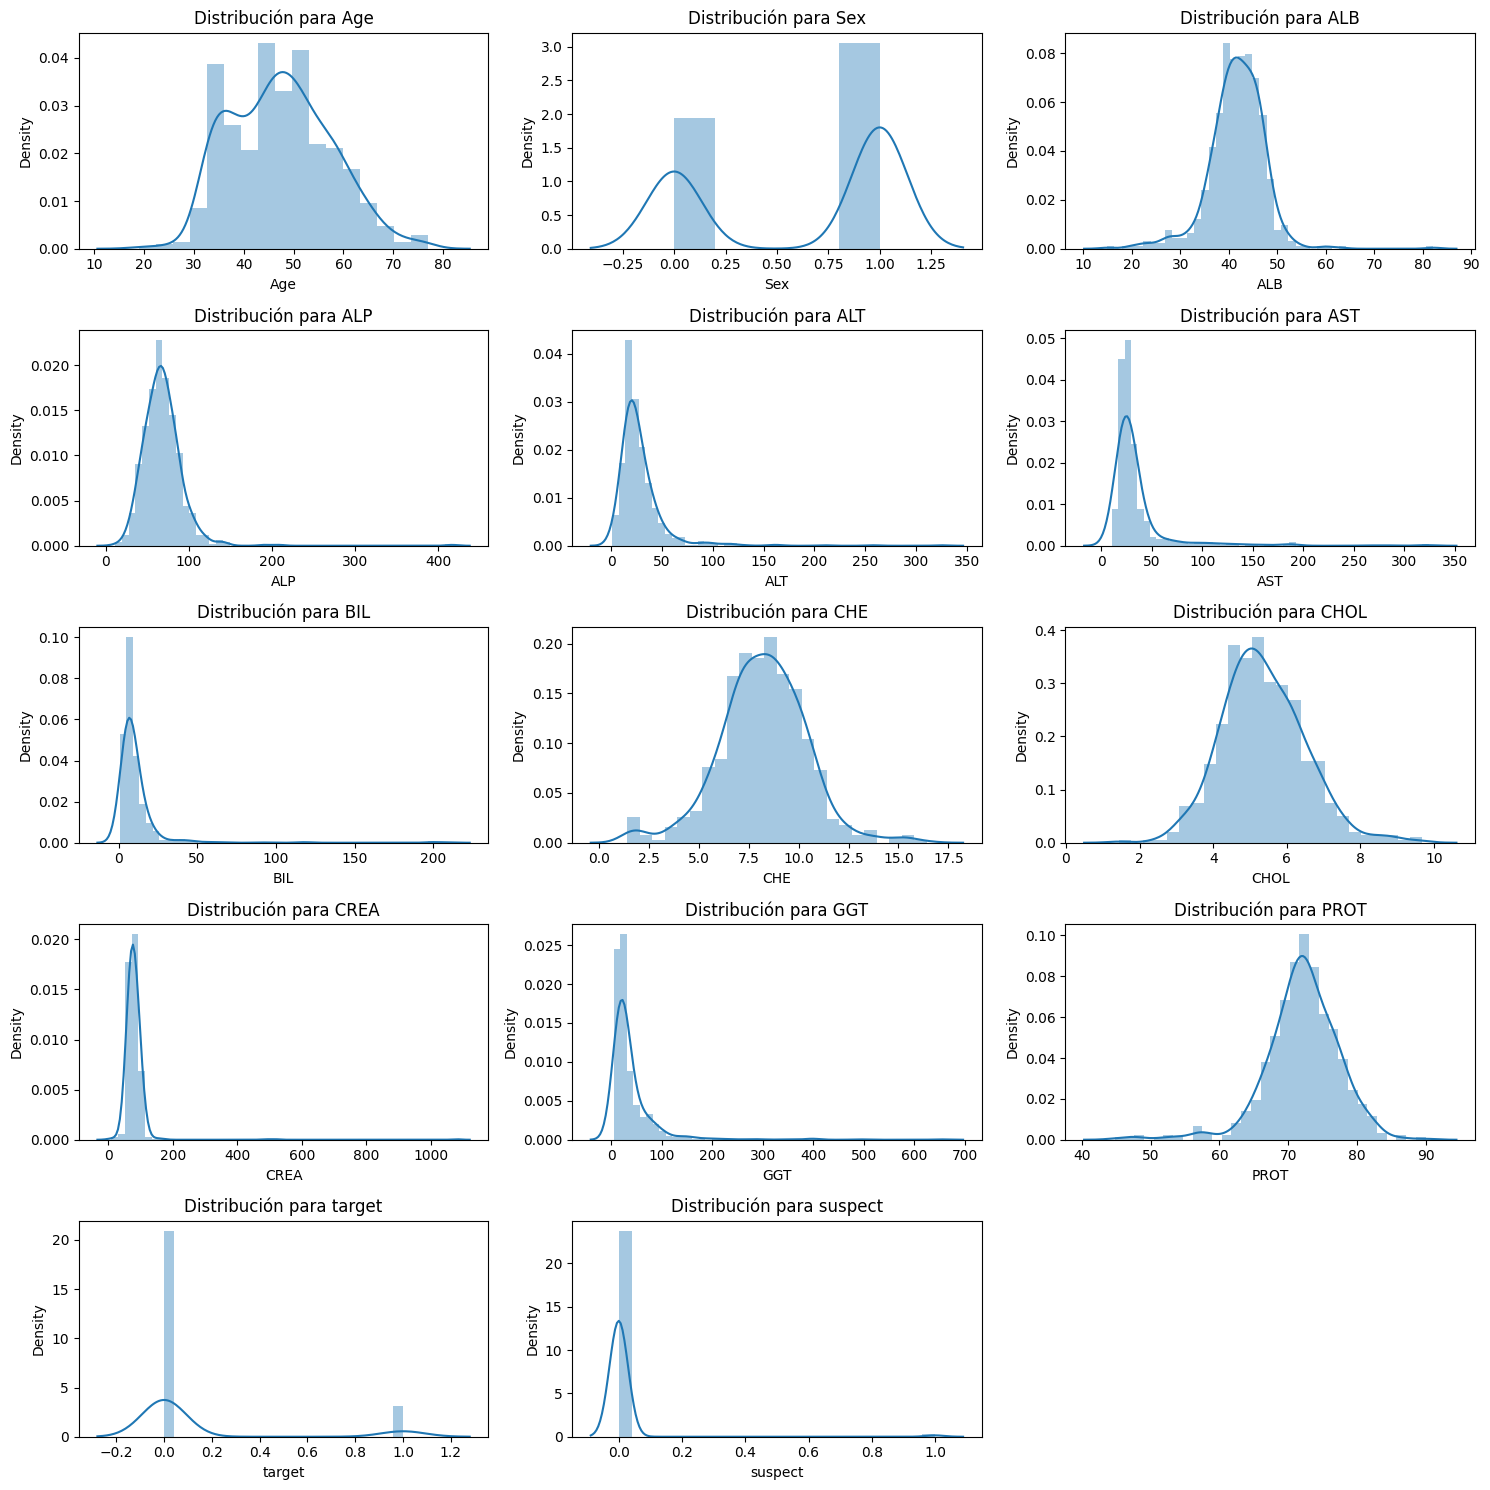

In [ ]:
graficos(calidad_datos(df), df, df.columns)


In [ ]:
B = df

In [ ]:
if A.equals(B):
   print("true")

true


In [ ]:
df.head(20)

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,target,suspect
0,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0,0
1,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0,0
2,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0,0
3,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0,0
4,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0,0
5,32,1,41.6,43.3,18.5,19.7,12.3,9.92,6.05,111.0,91.0,74.0,0,0
6,32,1,46.3,41.3,17.5,17.8,8.5,7.01,4.79,70.0,16.9,74.5,0,0
7,32,1,42.2,41.9,35.8,31.1,16.1,5.82,4.60,109.0,21.5,67.1,0,0
8,32,1,50.9,65.5,23.2,21.2,6.9,8.69,4.10,83.0,13.7,71.3,0,0
9,32,1,42.4,86.3,20.3,20.0,35.2,5.46,4.45,81.0,15.9,69.9,0,0


In [ ]:
df[df['suspect'] == 1]

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,target,suspect
533,47,1,22.5,124.0,79.5,46.7,2.3,6.83,4.30,170.0,345.6,58.6,1,1
534,48,1,24.9,116.9,49.2,24.3,4.9,3.44,5.25,29.0,83.0,47.8,1,1
535,49,1,21.6,42.2,9.5,10.6,2.4,3.75,3.01,64.0,38.9,44.8,1,1
536,55,1,47.3,106.0,208.8,130.6,0.8,14.80,8.08,76.0,71.6,78.3,1,1
537,71,1,14.9,69.8,19.7,95.2,9.8,13.30,2.61,9.0,7.6,47.0,1,1
538,74,1,20.3,84.0,22.8,43.0,5.7,4.91,3.19,52.0,218.3,47.8,1,1
539,59,0,19.3,208.2,325.3,146.6,6.9,5.33,4.72,32.0,295.6,53.1,1,1


In [ ]:
matriz_corr = df.corr()

<Axes: >

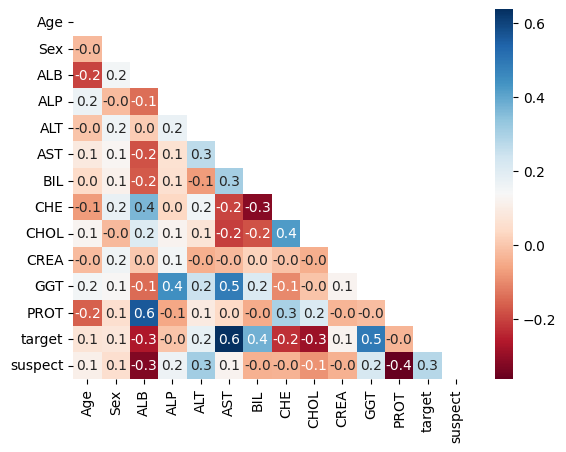

In [ ]:
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, cmap='RdBu', annot=True, fmt=".1f", mask=mask)

In [ ]:
df.drop(columns='suspect', inplace=True)

##f. Transforma las variables regresoras por medio de la estandarización. Muestra el antes y después de esta usando boxplots, y realiza una segmentación de la muestra en 33% para test y el resto para entrenamiento.

In [ ]:
df_antes = df

Separando el dataset en conjunts de test y entrenamiento

In [ ]:
X = df.drop(columns='target')
y = df['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.33, random_state = 42)

Escalándo sólo los datos de entrenamiento

In [ ]:
modelo_escalado = StandardScaler()
modelo_escalado.fit(X_train)

StandardScaler()

Escalando las variables independientes de train y test (X_train_ps y X_test_ps)

In [ ]:
X_train_ps = pd.DataFrame(modelo_escalado.transform(X_train), columns=X_train.columns, index = X_train.index)
X_test_ps = pd.DataFrame(modelo_escalado.transform(X_test), columns=X_test.columns, index = X_test.index)


In [ ]:
atributos = X_train.columns.to_list()

In [ ]:
atributos

['Age',
 'Sex',
 'ALB',
 'ALP',
 'ALT',
 'AST',
 'BIL',
 'CHE',
 'CHOL',
 'CREA',
 'GGT',
 'PROT']

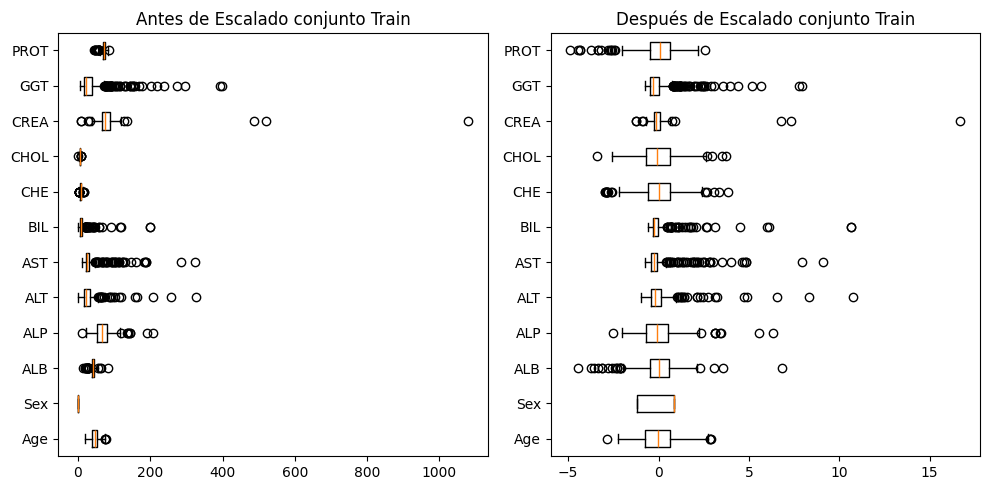

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].boxplot(X_train.loc[:,atributos], vert = False)
ax[0].set_yticks(np.arange(1, len(atributos)+1), atributos)
ax[0].set_title('Antes de Escalado conjunto Train')

ax[1].boxplot(X_train_ps.loc[:,atributos], vert = False)
ax[1].set_yticks(np.arange(1, len(atributos)+1), atributos)
ax[1].set_title('Después de Escalado conjunto Train')

plt.tight_layout()
plt.show()

#2. Modelo regresión logística con validación cruzada usando 5-fold, con regularización Elastic Net.

Hiper-parámetros:
- Cs: valores entre 0.01 y 5.0, con 200 valores lineales.
- l1_ratio: valores entre 0 y 1, con 200 valores lineales.

In [ ]:
Cs = list(np.linspace(0.01 , 5 , 200))
l1_ratio = list(np.linspace(0, 1 , 200))

In [ ]:
modelo_regresion_logistica = LogisticRegressionCV(cv = 5,
                                                  solver = 'saga',
                                                  max_iter = 1000,
                                                  penalty = 'elasticnet',
                                                  Cs = Cs,
                                                  l1_ratios = l1_ratio,
                                                  n_jobs = -1)

In [ ]:
modelo_regresion_logistica.fit(X_train_ps, y_train)

KeyboardInterrupt: 

In [ ]:
yhat_test_ps = modelo_regresion_logistica.predict(X_test_ps)

In [ ]:
print(classification_report(y_test, yhat_test_ps))

In [ ]:
coeficientes = pd.DataFrame({'Característica': atributos, 'Coeficiente': modelo_regresion_logistica.coef_[0]})
coeficientes['Coeficiente_Abs'] = np.abs(coeficientes['Coeficiente'])
coeficientes_ordenados = coeficientes.sort_values(by='Coeficiente_Abs', ascending=False)
display(coeficientes_ordenados)

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Característica', data=coeficientes_ordenados)
plt.title('Coeficientes del Modelo de Regresión Logística (Ordenados por valor absoluto)')
plt.xlabel('Valor del Coeficiente')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Mejor C: {modelo_regresion_logistica.C_}")
print(f"Mejor l1_ratio: {modelo_regresion_logistica.l1_ratio_}")

Basado en los coeficientes del modelo de regresión logística, las tres características con mayor incidencia en la predicción de si un sujeto tiene una posible enfermedad (Clase 1) son:

1.  **GGT (Gamma-glutamil transferasa):** Esta enzima puede estar relacionada con la función hepática. Un valor alto podría indicar daño hepático o problemas biliares, lo que la convierte en un fuerte predictor de la categoría de enfermedad.

2.  **BIL (Bilirrubina):** Un pigmento amarillo que puede aumentar en casos de problemas hepáticos. Niveles elevados de bilirrubina son un indicador conocido de disfunción hepática, lo que la hace una característica muy influyente en la predicción.

3.  **PROT (Proteínas totales):** Incluyen varias proteínas, como albúmina y globulinas. Los cambios en los niveles de proteínas totales pueden reflejar el estado de la función hepática o nutricional, siendo un factor importante en el diagnóstico de enfermedades.

Estas características sugieren que los marcadores bioquímicos relacionados con la función hepática son cruciales para diferenciar a los individuos con posibles enfermedades de los donantes de sangre sanos.

#3. Modelo Extreme Gradient Boosting con búsqueda de hiperparámetros de grilla, con regularización para la combinación L1 y L2.

 - a. reg_lambda: valores entre 0.0 y 2.0, con 10 valores lineales.
 - b. reg_alpha: valores entre 0 y 1, con 10 valores lineales.
- c. learning_rate: valores entre 0.1 a 10, con 20 valores lineales.

In [ ]:
param_grid = {
    'reg_lambda': np.linspace(0.0, 2.0, 10, dtype=float),
    'reg_alpha': np.linspace(0.0, 1.0, 10,dtype=float),
    'learning_rate': np.linspace(0.1, 10, 20, dtype=float)
}

grid_xgbRF = GridSearchCV(XGBRFClassifier(), param_grid=param_grid, cv=5, n_jobs=-1)
grid_xgbRF.fit(X_train_ps, y_train)



4. Importancia de los atributos,valores óptimos de hiperparámetros y métricas modelo XGBoostRF

In [ ]:
print(f'Los mejores parámetros del modelo son:\n{grid_xgbRF.best_params_}')

In [ ]:
yhat_test_xgbRF = grid_xgbRF.best_estimator_.predict(X_test_ps)
print(classification_report(y_test, yhat_test_xgbRF))

In [ ]:
feature_importances = grid_xgbRF.best_estimator_.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df_sorted = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_sorted)
plt.title('Importancia de las Características para el Modelo XGBoostRF')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

5. **CONCLUSION:**

 Se recomienda el uso del modelo XGBoostRF dado que, dada la naturaleza del problema, es más apropiado priorizar el recall de los casos verdaderos (identificar realmente los casos en los cuales hay un riesgo potencial de enfermedad en la sangre).

El modelo XBoostRF es mejor que el modelo de regresón logística, identificando correctamente donde realmente hay una enfermedad, reduciendo el riesgo (probabilidad) de pasar por alto una muestra que debería ser clasificada como "**enfermedad**".